# 02_Model_Training
# Diabetes Classification Models

In [1]:
# 导入包
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint
from scipy.stats import uniform

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    RepeatedStratifiedKFold)

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

# Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
)
from sklearn.svm import SVC

from sklearn.ensemble import HistGradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
# 创建存放结果的文件夹
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

# 数据
df = pd.read_csv(
    r"D:\Desktop\ai4bio\期末项目\diabetes_binary_health_indicators_BRFSS2015.csv")

TARGET = "Diabetes_binary"

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [3]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (202944, 21)
Test : (50736, 21)


In [4]:
# 交叉验证（Cross-Validation, CV）
cv = RepeatedStratifiedKFold(
    n_splits=5,     # 5折
    n_repeats=1,    # 重复一次
    random_state=42)

# 模型与参数空间
models = {}

# 1. Logistic Regression (本来就快，稍微缩小范围)
models["Logistic Regression"] = {
    "model": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000, random_state=42, class_weight='balanced'))
    ]),
    "params": {
        "clf__C": uniform(0.01, 10),
        "clf__penalty": ["l2"]
    },
    "n_iter": 10  # 从20减到10
}

# 2. Decision Tree (必须严格限制深度，否则极慢且过拟合)
models["Decision Tree"] = {
    "model": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "params": {
        "max_depth": randint(3, 10),          # 限制最大深度，20太深了
        "min_samples_split": [50, 100, 200],  # 用列表代替randint，强制节点样本数，极大提速
        "min_samples_leaf": [20, 50, 100]
    },
    "n_iter": 10
}

# 3. Random Forest (大幅缩减树的数量和深度)
models["Random Forest"] = {
    "model": RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    "params": {
        "n_estimators": randint(50, 200),     # 7万数据200棵足够了，600太慢
        "max_depth": randint(3, 10),          # 限制深度
        "min_samples_split": [50, 100, 200],  # 限制分裂，防止树长得太细
        "min_samples_leaf": [20, 50, 100]
    },
    "n_iter": 10
}

# 4. Extra Trees (同上)
models["Extra Trees"] = {
    "model": ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    "params": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(3, 10),
        "min_samples_split": [50, 100, 200],
        "min_samples_leaf": [20, 50, 100]
    },
    "n_iter": 10
}


# 5. Hist Gradient Boosting
models["Hist Gradient Boosting"] = {
    "model": HistGradientBoostingClassifier(
        random_state=42,
        class_weight='balanced',  # 记得在这里加上处理不平衡的参数！
        early_stopping=True,      # 额外建议：开启早停，防止过拟合且能稍微提速
        validation_fraction=0.1,  # 留10%的数据做早停验证
        n_iter_no_change=10       # 连续10次迭代没提升就停止
    ),
    "params": {
        "max_iter": randint(50, 150),      # 注意：参数名改成了 max_iter！
        "learning_rate": [0.05, 0.1, 0.2], 
        "max_depth": randint(2, 6)         
    },
    "n_iter": 10
}



# 6. XGBoost (已经用了hist，很快，稍微优化)
models["XGBoost"] = {
    "model": XGBClassifier(
        eval_metric="logloss",
        random_state=42,
        tree_method="hist",
        n_jobs=-1,
        scale_pos_weight = 6.18
    ),
    "params": {
        "n_estimators": randint(50, 200),
        "max_depth": randint(3, 8),
        "learning_rate": [0.05, 0.1, 0.2],
        "subsample": [0.8, 1.0],              # 缩小范围
        "colsample_bytree": [0.8, 1.0]
    },
    "n_iter": 10
}

# 7. LightGBM (本身极快，稍微优化)
models["LightGBM"] = {
    "model": LGBMClassifier(random_state=42, verbose=-1, n_jobs=-1, is_unbalance=True), # 记得加 n_jobs
    "params": {
        "n_estimators": randint(50, 200),
        "num_leaves": randint(20, 50),        # 缩小范围
        "learning_rate": [0.05, 0.1, 0.2],
        "max_depth": randint(3, 8)
    },
    "n_iter": 10
}

In [5]:
# 模型训练
performance = []
best_models = {}
predictions = {}

for name, info in models.items():

    print("\n"+"="*60)
    print(name)
    print("="*60)

    search = RandomizedSearchCV(
        estimator=info["model"],
        param_distributions=info["params"],
        n_iter=info["n_iter"],
        scoring="average_precision",
        cv=cv,
        n_jobs=32,
        random_state=42,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("\nBest Parameters:")
    print(search.best_params_)

    best_models[name] = best_model

 
    # Prediction
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    predictions[name] = {
        "y_pred":y_pred,
        "y_prob":y_prob
    }

    # 评价指标计算
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    performance.append([name, acc, precision, recall, f1, auc, ap])


Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'clf__C': np.float64(0.5908361216819946), 'clf__penalty': 'l2'}

Decision Tree
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'max_depth': 9, 'min_samples_leaf': 100, 'min_samples_split': 200}

Random Forest
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'max_depth': 9, 'min_samples_leaf': 20, 'min_samples_split': 200, 'n_estimators': 156}

Extra Trees
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'max_depth': 9, 'min_samples_leaf': 20, 'min_samples_split': 200, 'n_estimators': 156}

Hist Gradient Boosting
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 79}

XGBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 4, '

In [6]:
# Performance Table
performance_df = pd.DataFrame(
    performance,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"])

performance_df = performance_df.sort_values("ROC_AUC", ascending=False)
print("\n")
print(performance_df)

performance_df.to_csv("results/performance_summary.csv", index=False)



                    Model  Accuracy  Precision    Recall        F1   ROC_AUC  \
6                LightGBM  0.719391   0.305534  0.796577  0.441664  0.827177   
4  Hist Gradient Boosting  0.718011   0.304484  0.797284  0.440674  0.826983   
5                 XGBoost  0.720494   0.305747  0.791767  0.441143  0.826458   
2           Random Forest  0.720376   0.304020  0.781016  0.437671  0.821189   
0     Logistic Regression  0.731512   0.310749  0.761069  0.441309  0.819631   
1           Decision Tree  0.702815   0.290549  0.785825  0.424240  0.814830   
3             Extra Trees  0.703465   0.289840  0.778045  0.422346  0.809691   

     PR_AUC  
6  0.423205  
4  0.422162  
5  0.422556  
2  0.412236  
0  0.392585  
1  0.400074  
3  0.393535  


In [7]:
# Save Models
joblib.dump(
    {
        "X_train":X_train,
        "X_test":X_test,
        "y_train":y_train,
        "y_test":y_test
    },
    "results/data_split.pkl"
)
joblib.dump(best_models, "results/best_models.pkl")
joblib.dump(predictions, "results/predictions.pkl")

['results/predictions.pkl']

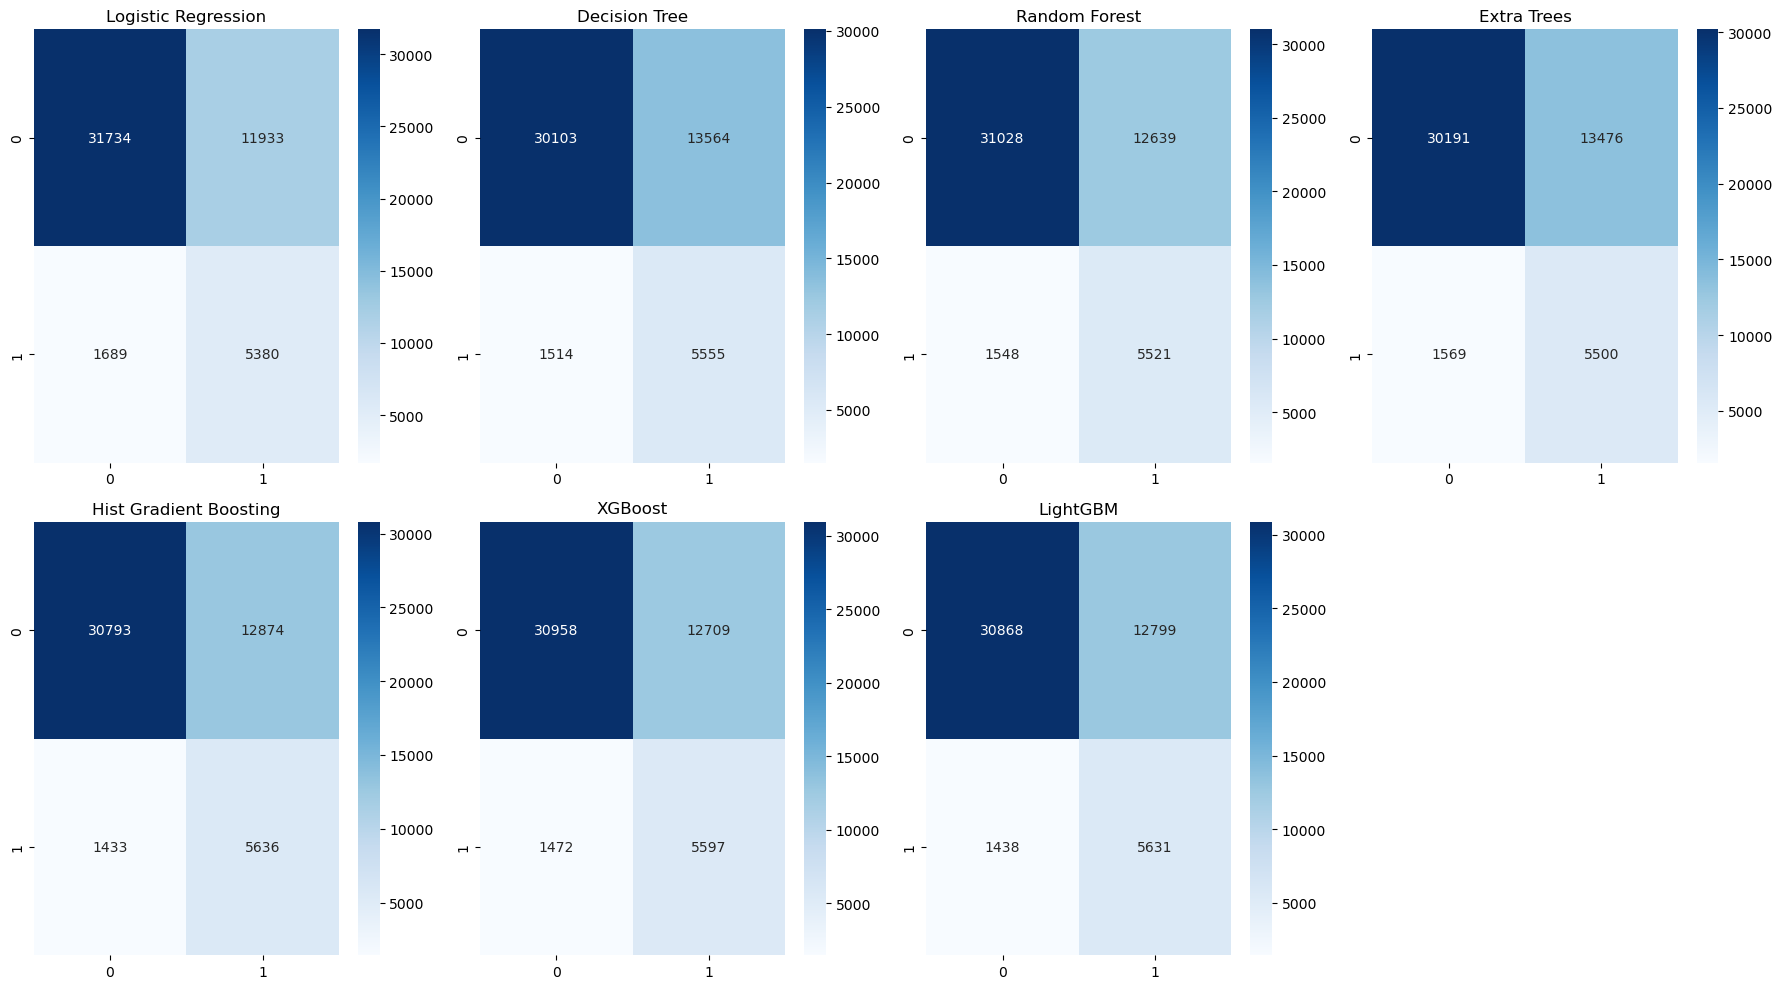

In [8]:
# Confusion Matrix
fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()

for ax, name in zip(
    axes,
    best_models.keys()
):
    cm = confusion_matrix(
        y_test,
        predictions[name]["y_pred"]
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax)
    ax.set_title(name)

# 隐藏多余的子图
axes[-1].set_visible(False)

plt.tight_layout()

plt.savefig(
    "figures/Confusion_Matrices.png",
    dpi=300)

plt.show()

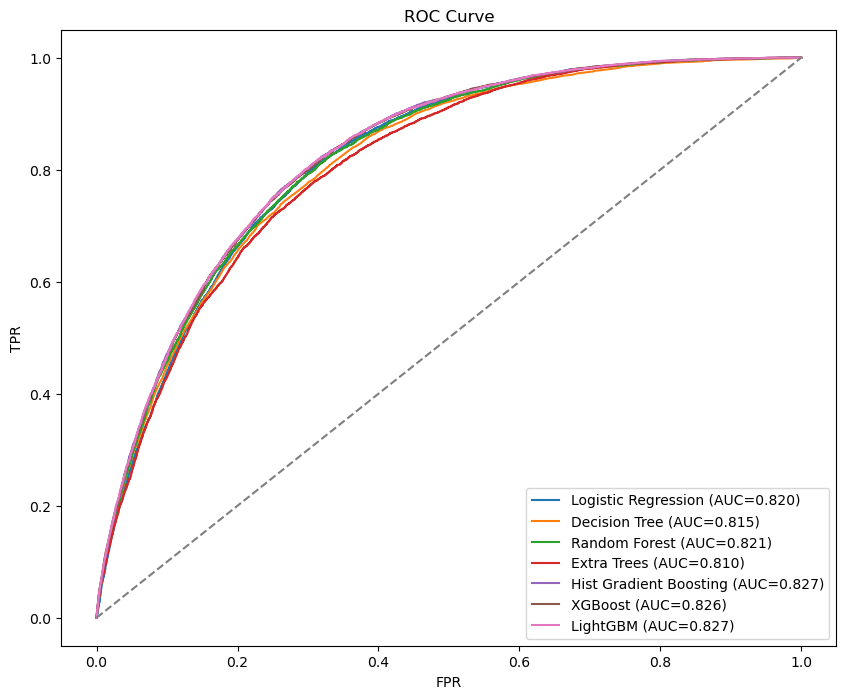

In [9]:
# ROC Curves
plt.figure(figsize=(10,8))

for name in best_models:
    y_prob = predictions[name]["y_prob"]
    fpr,tpr,_ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
)

plt.plot([0,1], [0,1], "--")

plt.legend()

plt.xlabel("FPR")
plt.ylabel("TPR")

plt.title("ROC Curve")

plt.savefig(
    "figures/ROC_Curves.png",
    dpi=300)

plt.show()

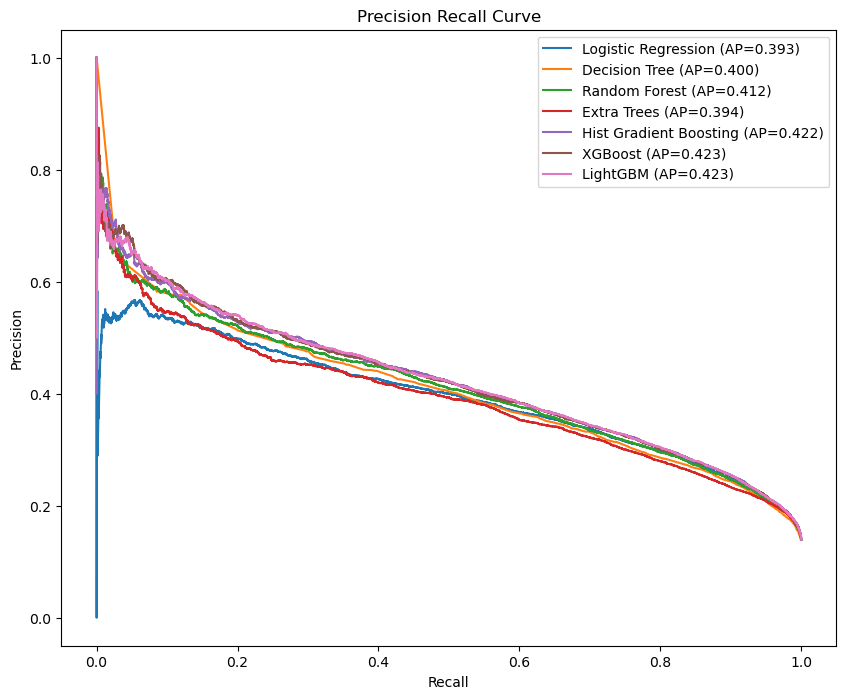


训练完成


In [10]:
# PR Curve

plt.figure(figsize=(10,8))

for name in best_models:
    y_prob = predictions[name]["y_prob"]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)

    ap = average_precision_score(y_test, y_prob)

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})")

plt.legend()

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.savefig("figures/PR_Curves.png", dpi=300)

plt.show()

print("\n训练完成")

In [11]:
# 只保留前8个重要特征
important_features = [
    'GenHlth', 'HighBP', 'BMI', 'Age', 'HighChol', 
    'Income', 'Sex', 'CholCheck'
]

X_train_reduced = X_train[important_features]
X_test_reduced = X_test[important_features]


# 重新训练
# Hist Gradient Boosting
search_new = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        random_state=42,
        class_weight='balanced',  # 记得在这里加上处理不平衡的参数！
        early_stopping=True,      # 额外建议：开启早停，防止过拟合且能稍微提速
        validation_fraction=0.1,  # 留10%的数据做早停验证
        n_iter_no_change=10       # 连续10次迭代没提升就停止
    ),
    param_distributions={
        "max_iter": randint(50, 150),      # 注意：参数名改成了 max_iter！
        "learning_rate": [0.05, 0.1, 0.2], 
        "max_depth": randint(2, 6)         
    },
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    n_jobs=32,
    random_state=42,
    verbose=1
)

search_new.fit(X_train_reduced, y_train)

print("\nBest Parameters:")
print(search.best_params_)

# Prediction
y_pred = search_new.predict(X_test_reduced)
y_prob = search_new.predict_proba(X_test_reduced)[:,1]

# 评价指标计算
performance_new = []

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
performance_new.append(["Hist Gradient Boosting", acc, precision, recall, f1, auc, ap])

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 124, 'num_leaves': 30}


In [12]:
# Performance Table
performance_df = pd.DataFrame(
    performance_new,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"])

performance_df = performance_df.sort_values("ROC_AUC", ascending=False)
print("\n")
print(performance_df)

# Save Models
joblib.dump(search_new, "results/best_models_reduced.pkl")



                    Model  Accuracy  Precision   Recall       F1   ROC_AUC  \
0  Hist Gradient Boosting  0.713517   0.300715  0.79686  0.43665  0.823236   

     PR_AUC  
0  0.415798  


['results/best_models_reduced.pkl']

正在绘制 Logistic Regression 的学习曲线，请稍候...
正在绘制 Decision Tree 的学习曲线，请稍候...
正在绘制 Random Forest 的学习曲线，请稍候...
正在绘制 Extra Trees 的学习曲线，请稍候...
正在绘制 Hist Gradient Boosting 的学习曲线，请稍候...
正在绘制 XGBoost 的学习曲线，请稍候...
正在绘制 LightGBM 的学习曲线，请稍候...


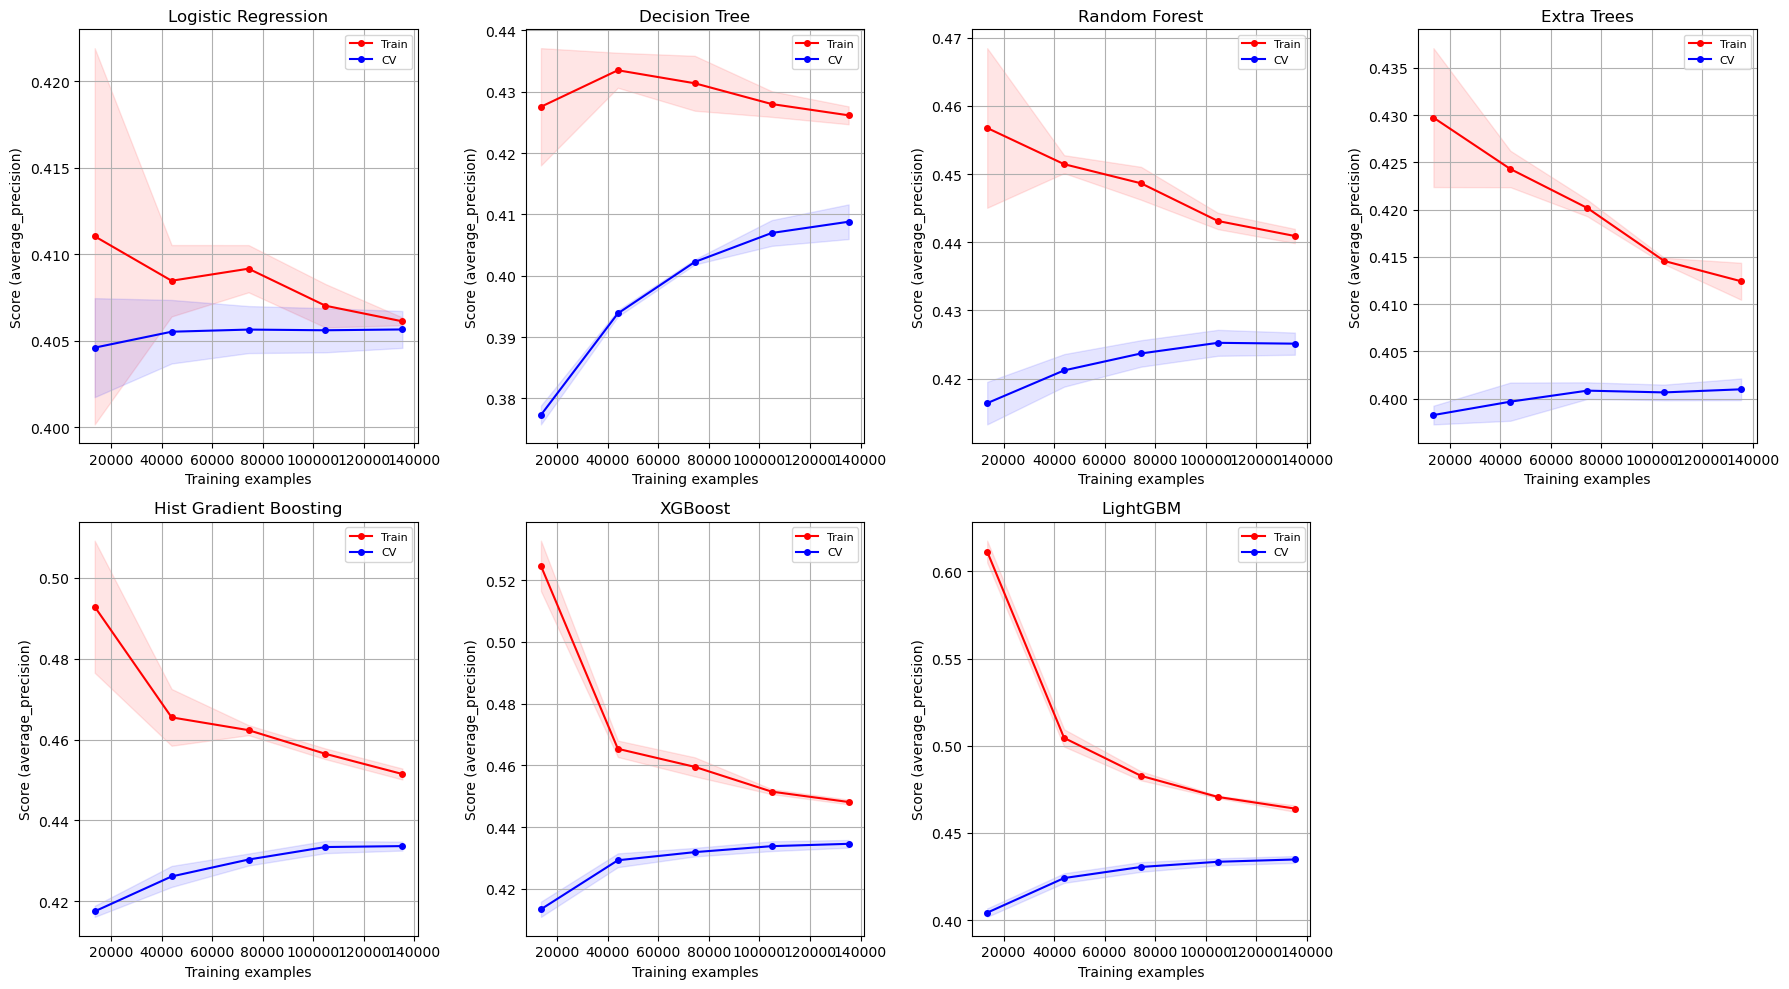

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import warnings
warnings.filterwarnings('ignore')

# Learning Curves (scoring='average_precision')
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, name in zip(axes, best_models.keys()):
    print(f"正在绘制 {name} 的学习曲线，请稍候...")
    
    train_sizes, train_scores, test_scores = learning_curve(
        best_models[name], X_train, y_train,
        cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='average_precision',  # ✅ 已更改
        random_state=42
    )
    
    ax.set_title(name)
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Score (average_precision)")  # ✅ 标签同步更新
    
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color="r", label="Train", markersize=4)
    ax.fill_between(train_sizes, 
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1), 
                    alpha=0.1, color="r")
    
    ax.plot(train_sizes, test_scores.mean(axis=1), 'o-', color="b", label="CV", markersize=4)
    ax.fill_between(train_sizes, 
                    test_scores.mean(axis=1) - test_scores.std(axis=1),
                    test_scores.mean(axis=1) + test_scores.std(axis=1), 
                    alpha=0.1, color="b")
    
    ax.grid(True)
    ax.legend(loc="best", fontsize=8)

# 隐藏多余的子图
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig("figures/Learning_Curves.png", dpi=300)
plt.show()